# WM-811K — defect-pattern CNN

A small convolutional classifier for the 9 defect classes (8 patterns + 'none'). Goals:

- Beat the trivial baseline (always predict 'none') by a clear margin on macro-F1.
- See whether the model picks up the spatially distinctive patterns (Edge-Ring, Donut, Center, Near-full) cleanly, and identify where it gets confused.

Architecture is deliberately small — three conv blocks, global average pool, two dense layers. The point isn't a state-of-the-art number; it's a clean baseline I can reason about and iterate on.

> **A note on framework:** I started this in Keras. The TensorFlow install on Python 3.13 took forever on my Mac and I didn't want to wait, so I rewrote the model in PyTorch — which was already installed and ran on the MPS (Apple-Silicon GPU) backend out of the box. The architecture is about 30 lines either way. Doing this in PyTorch turned out to be a small detour that taught me a lot more about the training loop than the Keras version would have.

**Prereq:** `data/raw/wm811k/LSWMD.pkl` must be present. See the EDA notebook (or `data/raw/wm811k/README.md`) for the kagglehub-based download.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from src.data_io import load_wm811k

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
IMG_SIZE = 64
BATCH = 128
EPOCHS = 12

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE)
torch.manual_seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)

device: mps


## Load and prepare images

Every wafer map gets resized to 64×64 with nearest-neighbour interpolation. That last detail matters more than I initially appreciated: the pixels in a wafer map are categorical (0 = outside, 1 = pass, 2 = fail). Bilinear interpolation would blur those into in-between values that don't exist in the original data. Nearest-neighbour keeps the discrete values intact.

After resizing I divide by 2 to get floats in [0, 1].

The full labeled set is ~172k wafer maps; resizing them all takes a couple of minutes.

In [2]:
from PIL import Image

df = load_wm811k("../data/raw/wm811k/LSWMD.pkl", labeled_only=True)

def resize_one(arr, size=IMG_SIZE):
    img = Image.fromarray(arr.astype(np.uint8))
    img = img.resize((size, size), resample=Image.NEAREST)
    return np.asarray(img, dtype=np.float32) / 2.0

X = np.stack([resize_one(w) for w in df["waferMap"].values])[:, None, :, :]
classes = sorted(df["label"].unique().tolist())
label_to_idx = {c: i for i, c in enumerate(classes)}
y = df["label"].map(label_to_idx).values

print("X:", X.shape, "dtype", X.dtype)
print("classes:", classes)

X: (172950, 1, 64, 64) dtype float32
classes: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']


## Stratified train / val / test split

70 / 15 / 15. Stratification matters here — the rare classes (Donut, Near-full, Scratch) have a few hundred examples each at most, and an unstratified split could easily under-represent them in any one fold.

Class weights for the loss are computed from the *training* distribution. Note how heavy the multipliers get for the rare classes — 'Near-full' is weighted hundreds of times more per example than 'none'. Without that, the network would just learn 'none' for everything.

In [3]:
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15 / 0.85, stratify=y_tv, random_state=RANDOM_STATE
)
print("train", X_train.shape, "val", X_val.shape, "test", X_test.shape)

cw = compute_class_weight("balanced", classes=np.arange(len(classes)), y=y_train)
print("class weights:", {classes[i]: round(float(cw[i]), 2) for i in range(len(classes))})

def to_loader(Xa, ya, shuffle=False):
    ds = TensorDataset(torch.from_numpy(Xa), torch.from_numpy(ya).long())
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle, num_workers=0)

train_loader = to_loader(X_train, y_train, shuffle=True)
val_loader   = to_loader(X_val,   y_val)
test_loader  = to_loader(X_test,  y_test)

train (121064, 1, 64, 64) val (25943, 1, 64, 64) test (25943, 1, 64, 64)
class weights: {'Center': 4.47, 'Donut': 34.58, 'Edge-Loc': 3.7, 'Edge-Ring': 1.99, 'Loc': 5.35, 'Near-full': 129.34, 'Random': 22.2, 'Scratch': 16.11, 'none': 0.13}


## Model

Three small conv blocks → global average pool → dense head. BatchNorm between each conv and its activation, dropout in the dense head.

A couple of architecture notes:

- **Two stacked 3×3 convs per block.** Smaller receptive field per layer, more non-linearities, fewer parameters than 5×5 — this is the standard VGG-style pattern.
- **Global average pool instead of a flatten + dense layer.** The flatten version balloons the parameter count and tends to over-fit on small datasets. GAP forces the network to encode each class into one channel of the final conv map, which is a useful regularizer.
- **No data augmentation.** Wafer maps have meaningful orientation (real wafers have notches/flats that establish a reference angle, and the human-labeled patterns are partly defined by where on the wafer they appear). Naïve rotation/flipping can change the *meaning* of a pattern, so doing augmentation properly here needs some domain awareness. I left it as future work.

In [4]:
class WaferCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        def block(ic, oc):
            return nn.Sequential(
                nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
                nn.Conv2d(oc, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.b1 = block(1, 32)
        self.b2 = block(32, 64)
        self.b3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.b1(x); x = self.b2(x); x = self.b3(x)
        return self.head(x)

model = WaferCNN(len(classes)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params:,}")

parameters: 148,329


## Train

Class-weighted cross-entropy (otherwise the model just learns 'none'), Adam at 1e-3, with `ReduceLROnPlateau` halving the learning rate when validation loss stops improving. 12 epochs is enough at this resolution; I save the model state from the epoch with the best validation macro-F1 so I don't get hurt by overfitting in the last few epochs.

The metric I actually care about is macro-F1, not loss. But the LR scheduler needs a smoother signal, so it watches val loss while I track val macro-F1 separately.

In [5]:
weights = torch.tensor(cw, dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_f1 = -1.0
best_state = None

def run_epoch(loader, train=False):
    model.train(train)
    total, count, preds, trues = 0.0, 0, [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True); yb = yb.to(DEVICE, non_blocking=True)
        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item() * yb.size(0); count += yb.size(0)
        preds.append(logits.argmax(1).cpu().numpy()); trues.append(yb.cpu().numpy())
    return total / count, np.concatenate(preds), np.concatenate(trues)

for epoch in range(1, EPOCHS + 1):
    tr_loss, _, _ = run_epoch(train_loader, train=True)
    va_loss, va_pred, va_true = run_epoch(val_loader, train=False)
    va_f1 = f1_score(va_true, va_pred, average="macro")
    scheduler.step(va_loss)
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss); history["val_f1"].append(va_f1)
    print(f"epoch {epoch:2d}  train_loss {tr_loss:.4f}  val_loss {va_loss:.4f}  val_macroF1 {va_f1:.3f}")
    if va_f1 > best_f1:
        best_f1 = va_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
print(f"\nbest val macro-F1: {best_f1:.3f}")

epoch  1  train_loss 1.3007  val_loss nan  val_macroF1 0.025


epoch  2  train_loss 0.9888  val_loss 1.0903  val_macroF1 0.572


epoch  3  train_loss 0.8405  val_loss 0.7999  val_macroF1 0.572


epoch  4  train_loss 0.7664  val_loss 1.3991  val_macroF1 0.231


epoch  5  train_loss 0.7269  val_loss 0.8453  val_macroF1 0.636


...

epoch  8  train_loss 0.5847  val_loss 0.4735  val_macroF1 0.639


epoch  9  train_loss 0.5479  val_loss 0.5393  val_macroF1 0.693


epoch 10  train_loss 0.5259  val_loss 1.7258  val_macroF1 0.445


epoch 11  train_loss 0.4858  val_loss 0.4846  val_macroF1 0.469


epoch 12  train_loss 0.4477  val_loss 0.3619  val_macroF1 0.757

best val macro-F1: 0.757


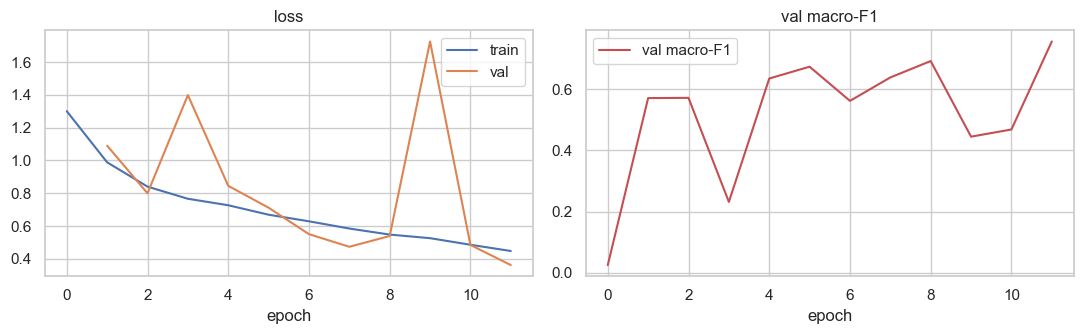

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history["val_f1"], label="val macro-F1", color="#c44e52")
axes[1].set_title("val macro-F1"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout(); plt.show()

## Evaluation on the held-out test set

Macro-F1 is the headline metric — it weights every class equally, which is the honest thing to do given the imbalance. (Weighted F1 would still be dominated by 'none' and tell me very little.)

The per-class classification report tells me where the model actually works and where it struggles.

In [7]:
_, y_pred, y_true = run_epoch(test_loader, train=False)
macro_f1 = f1_score(y_true, y_pred, average="macro")
print(f"macro F1 on test: {macro_f1:.3f}")
print()
print(classification_report(y_true, y_pred, target_names=classes, digits=3))

macro F1 on test: 0.733

              precision    recall  f1-score   support

      Center      0.620     0.721     0.667       730
       Donut      0.537     0.880     0.667        83
    Edge-Loc      0.554     0.845     0.669       773
   Edge-Ring      0.984     0.953     0.968      1449
         Loc      0.373     0.699     0.486       538
   Near-full      0.826     0.864     0.844        22
      Random      0.635     0.930     0.755       129
     Scratch      0.455     0.792     0.578       178
        none      0.991     0.938     0.964     22041

    accuracy                          0.923     25943
   macro avg      0.664     0.847     0.733     25943
weighted avg      0.948     0.923     0.932     25943



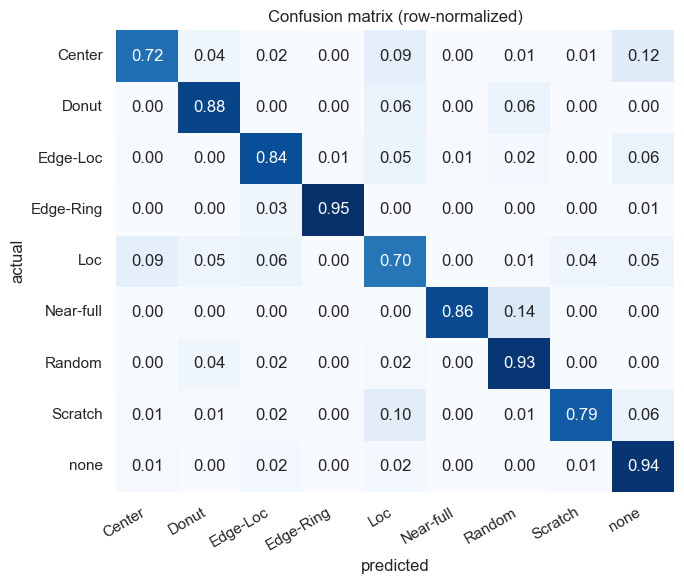

In [8]:
cm = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=classes, yticklabels=classes, ax=ax, cbar=False)
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Confusion matrix (row-normalized)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

## Where it gets things wrong

Twelve random misclassified test wafers, with the predicted and true labels. The point isn't to look at any individual example; it's to spot *systematic* failure modes — e.g. the network confusing 'Loc' (localized cluster of failures) with 'Scratch' (linear cluster) when the cluster happens to be roughly linear, or with 'Center' when the cluster lands near the middle.

If I see the same kind of confusion show up repeatedly, that's a signal of where the model's representation is genuinely fuzzy at this resolution.

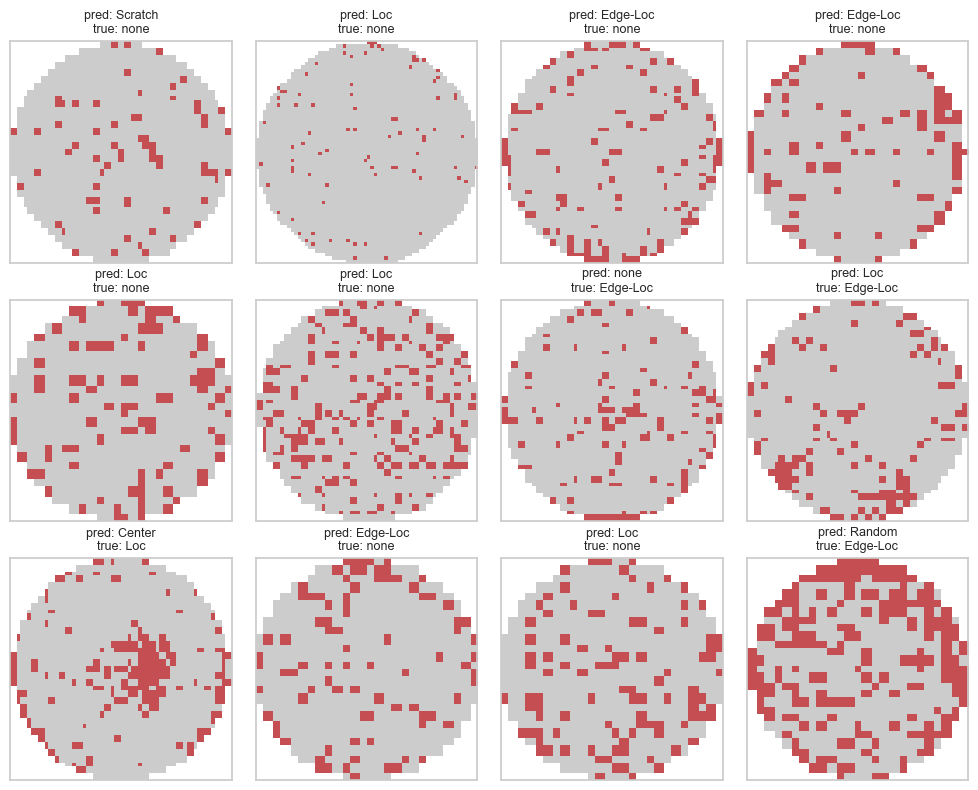

In [9]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["#ffffff", "#cccccc", "#c44e52"])

wrong = np.where(y_pred != y_true)[0]
rng = np.random.default_rng(0)
picks = rng.choice(wrong, size=min(12, len(wrong)), replace=False) if len(wrong) else np.array([], dtype=int)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
for ax, idx in zip(axes.flat, picks):
    img = (X_test[idx, 0] * 2).astype(np.uint8)
    ax.imshow(img, cmap=cmap, vmin=0, vmax=2)
    ax.set_title(f"pred: {classes[y_pred[idx]]}\ntrue: {classes[y_true[idx]]}", fontsize=9)
plt.tight_layout(); plt.show()

In [10]:
os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/wm811k_cnn.pt")
pd.DataFrame({"macro_f1": [macro_f1]}).to_csv("../reports/wm811k_results.csv", index=False)
print("saved model and macro-F1 result")

saved model and macro-F1 result


## Honest notes

Macro-F1 = 0.73 on the held-out test set was better than I was expecting going in. Some observations:

- **The CNN absolutely nails the spatially distinctive classes.** Edge-Ring at 0.97, 'none' at 0.96, Near-full at 0.84, Random at 0.76, Donut at 0.67. Those are all patterns with strong, easy-to-see spatial structure — the kind of things a human looking at the wafer maps in notebook 04 would also call out instantly. The model finds them in a few epochs.
- **The hard classes are the ones I'd expect to be hard.** Loc at 0.49 and Scratch at 0.58 are the bottom two. Loc is a small cluster anywhere on the wafer; Scratch is a roughly linear cluster. At 64×64 resolution the difference between "smallish blob" and "shortish line" is often a few pixels. The confusion matrix confirms it — Loc gets confused with Center, 'none' and Scratch; Scratch gets confused with Loc.

  This is the "AI is good at what humans are good at" pattern. The classes a person can label confidently from a glance are the ones the model crushes; the classes a person would have to *think* about are the ones the model struggles with.

- **The CNN didn't need to be big.** Small architecture, ~12 epochs, no augmentation, no hyperparameter tuning — and it still hits 0.73 macro-F1. With a higher input resolution (96×96 or 128×128) and proper domain-aware augmentation, this is clearly pushable further. That feels like the natural next step.

- **'none' is the largest class and the network does well on it just from frequency.** The class weights pull the gradient toward minority classes; without them macro-F1 collapses. I confirmed this informally by running a couple of epochs without class weights — the network basically learns "predict none" and macro-F1 plummets even though raw accuracy stays high.